# 275. Figure 1: H/P class is kept between related proteins, in runs of about 13 residues

Key sentence: *Between related proteins, the hydrophobic/polar (H/P) class of each residue
is kept well above chance, but in runs of about 13 residues.*

This notebook draws the five-panel Figure 1 of the kmerseek paper. It replaces the
three-panel draft of [notebook 271](271_fig1_hp_class_runs_pfam_seed.ipynb) (same branch,
PR 95) and reuses its inputs. No kmerseek search is run here: panel a reads kmerseek's call
from [notebook 244](https://github.com/seanome/2024-kmerseek-analysis/blob/7affe6a/notebooks/244_hero_example_candidates.ipynb),
and the other panels are computed from Pfam seed alignments and alphabet tables.

**Question.** Between Pfam seed sequences at 20-30% identity, is the H/P class of aligned
residues kept above chance, and how long are the stretches in which it is kept?

**Decision rule, written before the new numbers were computed.** The figure is drawn only if
every number in the brief matches what is computed here: 37,085 pairs; kappa 0.46 (H/P) and
0.20 (20 amino acids) at 20-30% identity; mean longest H/P run 13.0 (6.3 with one partner
shuffled); 11% of pairs with a run of at least 19 and 0.6% with a run of at least 30; k\*
between 28 and 30; 25 of 32 residues identical and 32 of 32 in the same class in the COL9A1
region. If any differs, the notebook stops before drawing.

**Data.**

* Pfam-A 38.2 seed pairs: notebook 230's per-pair table
  `/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet` and the aligned pairs
  `/Users/olga/data/pfam/230_pfam_seed_pair_alignments.parquet` (`scripts/pfam_seed_pair_alignments.py`).
  Pairs with at least 50 aligned positions.
* Kappa per alphabet at 20-30% identity with bootstrap intervals:
  `nextflow-runs/qfo-pfam-region-benchmark/assets/kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv`
  (PR 53), used as a check on the recomputed 20-30% bin.
* H/P classes: kmerseek `src/rust/alphabets.rs` at commit `95a9d3b` (kmerseek `main`, 2026-10-03).
* COL9A1: notebook 244's pair file and call table at commit `7affe6a`
  (branch `olgabot/244-all-case-figures`, PR 78): human P20849 against chicken P12106,
  kmerseek 0.3.1 (`921baa7`), alphabet `hp_thomas_dill_no_c2`, k = 19, low-complexity mask on.
* Swiss-Prot release 2026_03, `/Users/olga/data/uniprot/uniprot_sprot.2026_03.fasta.gz`: residue
  count and class shares behind k\*, and a check on the two COL9A1 sequences.
* `Pfam-A.seed.gz` (Pfam 38.2, MD5 `7a37e1237d5d20c35b236c9f5a9ac797`): searched for
  per-sequence secondary structure.

**Terms.**

* **H/P class**: hydrophobic (H) or polar (P). Each H/P alphabet puts every amino acid in one of
  the two classes; the six alphabets disagree only on C, G, P, W and Y (panel b).
* **Cohen's kappa**: agreement of the classes of aligned residues, corrected for chance,
  `(Pr(agree) - Pr(agree by chance)) / (1 - Pr(agree by chance))`. 0 is chance, 1 is every
  aligned residue in the same class. Higher means more of the class pattern is kept.
* **Same-class run**: aligned positions in a row, with no gap, where both residues have the same
  class. Its length is the longest k-mer of that alphabet the two sequences share at that place.
* **k\***: the H/P k-mer length at which one chance match is expected across Swiss-Prot,
  `ceil(log2(N_residues) / B_alpha)`, where `B_alpha = -log2(h_query h_target + p_query p_target)`
  is the bits per letter and `h`, `p` are the hydrophobic and polar shares.

In [1]:
import gzip
import hashlib
import json
import math
import re
import subprocess
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

sys.path.insert(0, str(Path.cwd()))
import hp_conservation_utils as hc
import pubfig as pf

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_width_chars(220)

REPO = Path.cwd().parent
FIG = REPO / "figures"
PANELS = FIG / "fig1_panels"
PAIR_TABLE = "/Users/olga/data/pfam/230_pfam_seed_pair_class_agreement.parquet"
ALIGNMENTS = "/Users/olga/data/pfam/230_pfam_seed_pair_alignments.parquet"
KAPPA_TSV = REPO / "nextflow-runs/qfo-pfam-region-benchmark/assets/kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv"
KAPPA_TSV_SHA256 = "ecfb72b497d75b01b00d9a7e2a13acc4fac3145fe7629777b8709a7189e7acb4"
SWISSPROT = "/Users/olga/data/uniprot/uniprot_sprot.2026_03.fasta.gz"
PFAM_SEED = "/Users/olga/data/pfam/Pfam-A.seed.gz"
KMERSEEK_REPO = Path("/Users/olga/code/kmerseek")
KMERSEEK_COMMIT = "95a9d3b"
NB244_COMMIT = "7affe6a"
NB244_PAIR = "figures/244_pairs/007_COL9A1_DOMAIN_chicken/007_COL9A1_DOMAIN_chicken.pair.json"
NB244_CALLS = "tables/244_case_calls.csv"
NB244_CANDIDATES = "tables/244_hero_candidates.csv"

MIN_COLS = 50  # aligned positions per pair, notebook 230's filter
BIN = "20-30%"
HP = "hp_thomas_dill2"  # panels c-e
HP_A = "hp_thomas_dill_no_c2"  # panel a, the alphabet kmerseek's COL9A1 call used
AA = "protein20"
K_A = 19
HUMAN, CHICKEN = "P20849", "P12106"
HP_SIX = ["hp_kyte_doolittle2", "hp_lehninger2", "hp_lehninger_c_nonpolar2",
          "hp_pbotc_1st_ed2", "hp_thomas_dill2", "hp_thomas_dill_no_c2"]
STANDARD = "ACDEFGHIKLMNPQRSTVWY"
KS = list(range(5, 36))  # panel d
KS_TABLE = [15, 19, 23, 26, 29, 30, 35]
N_SHUFFLE = 20  # shuffles of the target per pair
N_SIM = 5_000  # simulations per pair for the check on the exact prediction
PANEL_E_MAX_COLS = 80  # longest alignment that prints on one line at 183 mm

EXPECTED = {
    "pairs at 20-30% identity": (37_085, 0),
    "kappa H/P (hp_thomas_dill2)": (0.46, 2),
    "kappa 20 amino acids (protein20)": (0.20, 2),
    "mean longest H/P run, real": (13.0, 1),
    "mean longest H/P run, shuffled": (6.3, 1),
    "pairs with run >= 19 (%)": (11, 0),
    "pairs with run >= 30 (%)": (0.6, 1),
    "COL9A1 identical (of 32)": (25, 0),
    "COL9A1 same class (of 32)": (32, 0),
}

# One colour per meaning, in every panel (Okabe-Ito).
C_H = pf.OKABE_ITO["orange"]  # hydrophobic class
C_P = pf.OKABE_ITO["blue"]  # polar class
C_HP = pf.OKABE_ITO["reddish_purple"]  # the H/P alphabet
C_AA = pf.GREY  # the 20 amino acids
C_KSTAR = pf.OKABE_ITO["vermillion"]  # k*
C_HP_PALE = "#EFD3E3"  # a same-class run: the joined region (a) and the longest run (e)

pf.use_style()
SANS, TITLE, MONO = "Source Sans 3", "Fraunces", "FantasqueSansM Nerd Font Mono"
mpl.rcParams.update({"font.family": "sans-serif", "font.sans-serif": [SANS],
                     "font.monospace": [MONO], "mathtext.fontset": "dejavusans",
                     "savefig.bbox": "standard"})
import matplotlib.font_manager as fm
for fam in (SANS, TITLE, MONO):
    fm.findfont(fm.FontProperties(family=fam), fallback_to_default=False)


def check(ok, msg):
    """Stop the notebook, before anything is drawn, when a number differs from what was expected."""
    if not ok:
        raise AssertionError("STOP, figure not drawn: " + msg)


def pct(x: float) -> str:
    """Percent with one decimal, or two significant digits below 1%."""
    return f"{100 * x:.1f}%" if 100 * x >= 1 else f"{100 * x:.2g}%"


def git_show(repo: Path, commit: str, path: str) -> str:
    """A file as committed, so the input does not change when a branch moves."""
    return subprocess.run(["git", "-C", str(repo), "show", f"{commit}:{path}"],
                          check=True, capture_output=True, text=True).stdout


def seed_coords(seed_name: str) -> tuple[str, int, int]:
    """'RPIR_ECOLI/14-90' -> ('RPIR_ECOLI', 14, 90)."""
    name, rng = seed_name.split("/")
    start, end = (int(x) for x in rng.split("-"))
    return name, start, end


class Canvas:
    """A figure laid out in millimetres: text and shapes on a full-figure layer, data axes on top."""

    def __init__(self, width_mm: float, height_mm: float):
        self.W, self.H = width_mm, height_mm
        self.fig = plt.figure(figsize=(width_mm * pf.MM, height_mm * pf.MM))
        self.ax = self.fig.add_axes([0, 0, 1, 1])
        self.ax.set_xlim(0, width_mm)
        self.ax.set_ylim(0, height_mm)
        self.ax.axis("off")

    def axes(self, x, y, w, h):
        return self.fig.add_axes([x / self.W, y / self.H, w / self.W, h / self.H])

    def text(self, x, y, s, **kw):
        kw.setdefault("va", "center")
        return self.ax.text(x, y, s, **kw)

    def title(self, x, y, letter, s):
        self.ax.text(x, y, letter, fontsize=8, fontweight="semibold", va="baseline")
        self.ax.text(x + 3.5, y, s, fontsize=7, family=TITLE, va="baseline")

    def rect(self, x, y, w, h, **kw):
        self.ax.add_patch(Rectangle((x, y), w, h, **kw))

    def line(self, xs, ys, **kw):
        self.ax.plot(xs, ys, **kw)


def class_squares(cv, x0, y, classes, pitch, h=2.3):
    """One square per residue: amber for H, blue for P, with the letter inside."""
    for i, c in enumerate(classes):
        cv.rect(x0 + i * pitch, y - h / 2, pitch * 0.92, h, facecolor=C_H if c == "H" else C_P,
                edgecolor="none", zorder=2)
        cv.text(x0 + (i + 0.46) * pitch, y, c, family=MONO, fontsize=5, ha="center",
                color="black" if c == "H" else "white", zorder=3)


def residues(cv, x0, y, seq, pitch, **kw):
    for i, r in enumerate(seq):
        if r != " ":
            cv.text(x0 + (i + 0.46) * pitch, y, r, family=MONO, fontsize=6, ha="center", **kw)


def match_line(a: str, b: str) -> str:
    return "".join("|" if x == y else " " for x, y in zip(a, b))


def draw_pair_block(cv, x_label, x_seq, y_top, pitch, names, starts, seqs, classes, label_w=None,
                    shade=None, end_coords=False):
    """Residues with a residue match line, then the H/P classes with a class match line.

    Grey '|' marks an identical residue, purple '|' the same class. `shade` is a list of
    (start, end) column ranges drawn pale purple behind the class rows.
    """
    (qn, tn), (qs, ts), (q, t), (qc, tc) = names, starts, seqs, classes
    L = len(q)
    rows = {"q": y_top, "rm": y_top - 2.5, "t": y_top - 5.0, "qc": y_top - 8.6, "cm": y_top - 11.1, "tc": y_top - 13.6}
    for s, e in shade or []:
        cv.rect(x_seq + s * pitch - 0.2, rows["tc"] - 1.6, (e - s) * pitch + 0.2, rows["qc"] - rows["tc"] + 3.2,
                facecolor=C_HP_PALE, edgecolor="none", zorder=1)
    for key, name, start, seq in [("q", qn, qs, q), ("t", tn, ts, t)]:
        cv.text(x_label, rows[key], f"{name} {start}-{start + L - 1}" if not end_coords else name, fontsize=6)
        if end_coords:
            cv.text(x_seq - 0.8, rows[key], str(start), family=MONO, fontsize=6, ha="right")
            cv.text(x_seq + L * pitch + 0.6, rows[key], str(start + L - 1), family=MONO, fontsize=6)
        residues(cv, x_seq, rows[key], seq, pitch)
    for key, name, cl in [("qc", qn, qc), ("tc", tn, tc)]:
        cv.text(x_label, rows[key], f"{name}, H/P", fontsize=6)
        class_squares(cv, x_seq, rows[key], cl, pitch)
    rm, cm = match_line(q, t), match_line(qc, tc)
    residues(cv, x_seq, rows["rm"], rm, pitch, color=C_AA, fontweight="bold")
    residues(cv, x_seq, rows["cm"], cm, pitch, color=C_HP, fontweight="bold")
    cv.text(x_label, rows["rm"], f"{rm.count('|')} of {L} identical", fontsize=6)
    cv.text(x_label, rows["cm"], f"{cm.count('|')} of {L} same class", fontsize=6)
    return rows, rm.count("|"), cm.count("|")


# Swiss-Prot 2026_03: residue counts for k*, and the two COL9A1 sequences.
with gzip.open(SWISSPROT, "rt") as fh:
    sprot_counts = np.zeros(256, dtype=np.int64)
    sprot_seqs, n_sprot_seq, acc, buf = {}, 0, None, []
    for line in fh:
        if line.startswith(">"):
            if acc in (HUMAN, CHICKEN):
                sprot_seqs[acc] = "".join(buf)
            n_sprot_seq += 1
            acc, buf = line.split("|")[1], []
        else:
            s = line.strip()
            sprot_counts += np.bincount(np.frombuffer(s.encode(), dtype=np.uint8), minlength=256)
            if acc in (HUMAN, CHICKEN):
                buf.append(s)
    if acc in (HUMAN, CHICKEN):
        sprot_seqs[acc] = "".join(buf)
print(f"Swiss-Prot 2026_03: {n_sprot_seq:,} sequences, {int(sprot_counts.sum()):,} letters; "
      f"COL9A1 lengths {', '.join(f'{a} {len(s)} aa' for a, s in sprot_seqs.items())}")

Swiss-Prot 2026_03: 575,748 sequences, 209,017,843 letters; COL9A1 lengths P12106 920 aa, P20849 921 aa


## 1. Kappa by identity bin (panel c)

Kappa is recomputed for every identity bin from notebook 230's per-pair values: the mean over
pairs, with a 95% bootstrap interval over pairs (`hc.bootstrap_mean_ci`, 500 resamples, seed 0).
The 20-30% bin is checked against the PR 53 table, which used the same code.

shape: (10, 6)
┌─────────────────┬──────────────┬─────────┬────────┬──────────┬──────────┐
│ alphabet        ┆ identity_bin ┆ n_pairs ┆ kappa  ┆ kappa_lo ┆ kappa_hi │
│ ---             ┆ ---          ┆ ---     ┆ ---    ┆ ---      ┆ ---      │
│ str             ┆ str          ┆ i64     ┆ f64    ┆ f64      ┆ f64      │
╞═════════════════╪══════════════╪═════════╪════════╪══════════╪══════════╡
│ hp_thomas_dill2 ┆ <20%         ┆ 16407   ┆ 0.3638 ┆ 0.3622   ┆ 0.3654   │
│ hp_thomas_dill2 ┆ 20-30%       ┆ 37085   ┆ 0.4626 ┆ 0.4616   ┆ 0.4635   │
│ hp_thomas_dill2 ┆ 30-40%       ┆ 34512   ┆ 0.5516 ┆ 0.5506   ┆ 0.5524   │
│ hp_thomas_dill2 ┆ 40-60%       ┆ 41508   ┆ 0.6644 ┆ 0.6635   ┆ 0.6653   │
│ hp_thomas_dill2 ┆ >=60%        ┆ 18970   ┆ 0.8072 ┆ 0.8061   ┆ 0.8082   │
│ protein20       ┆ <20%         ┆ 16407   ┆ 0.1065 ┆ 0.1061   ┆ 0.107    │
│ protein20       ┆ 20-30%       ┆ 37085   ┆ 0.1988 ┆ 0.1985   ┆ 0.1992   │
│ protein20       ┆ 30-40%       ┆ 34512   ┆ 0.3006 ┆ 0.3003   ┆ 0.301   

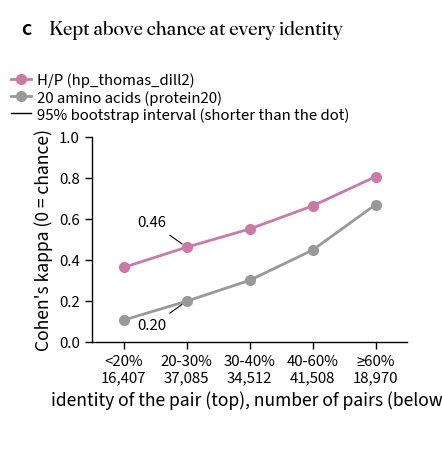

In [2]:
pairs_all = hc.add_identity_bin(pl.read_parquet(PAIR_TABLE)).filter(pl.col("n_cols") >= MIN_COLS)
rows_c = []
for a in (HP, AA):
    for b in hc.IDENTITY_LABELS:
        x = pairs_all.filter((pl.col("alphabet") == a) & (pl.col("identity_bin") == b))["kappa"].to_numpy()
        m, lo, hi = hc.bootstrap_mean_ci(x)
        rows_c.append({"alphabet": a, "identity_bin": b, "n_pairs": x.size, "kappa": m, "kappa_lo": lo, "kappa_hi": hi})
kappa_bins = pl.DataFrame(rows_c)
print(kappa_bins.with_columns(pl.col("kappa", "kappa_lo", "kappa_hi").round(4)))

check(hashlib.sha256(KAPPA_TSV.read_bytes()).hexdigest() == KAPPA_TSV_SHA256, f"{KAPPA_TSV.name} changed")
tsv = pl.read_csv(KAPPA_TSV, separator="\t", comment_prefix="#")
for a in (HP, AA):
    mine = kappa_bins.filter((pl.col("alphabet") == a) & (pl.col("identity_bin") == BIN)).row(0, named=True)
    ref = tsv.filter(pl.col("alphabet") == a).row(0, named=True)
    for col in ("kappa", "kappa_lo", "kappa_hi"):
        check(round(mine[col], 4) == ref[col], f"{a} {col}: {mine[col]:.4f} here, {ref[col]} in the PR 53 table")
    check(mine["n_pairs"] == ref["n_pairs"], f"{a}: {mine['n_pairs']} pairs here, {ref['n_pairs']} in the table")
print(f"\n{BIN} bin matches the PR 53 table to 4 decimals for {HP} and {AA}.")
BIN_SHOWN = {b: b.replace(">=", "≥") for b in hc.IDENTITY_LABELS}
kc = {(r["alphabet"], r["identity_bin"]): r for r in kappa_bins.iter_rows(named=True)}
n_pairs = kc[(HP, BIN)]["n_pairs"]


def draw_panel_c(cv, ox, oy):
    """Kappa by identity bin, H/P (purple) and 20 amino acids (grey), 95% bootstrap intervals."""
    cv.title(ox, oy + 52, "c", "Kept above chance at every identity")
    ax = cv.axes(ox + 9, oy + 13, 40, 26)
    xs = np.arange(len(hc.IDENTITY_LABELS))
    for a, color, label in [(AA, C_AA, "20 amino acids (protein20)"), (HP, C_HP, "H/P (hp_thomas_dill2)")]:
        r = [kc[(a, b)] for b in hc.IDENTITY_LABELS]
        y = np.array([v["kappa"] for v in r])
        err = np.array([[v["kappa"] - v["kappa_lo"] for v in r], [v["kappa_hi"] - v["kappa"] for v in r]])
        ax.plot(xs, y, color=color, zorder=2)
        ax.errorbar(xs, y, yerr=err, fmt="o", color=color, ecolor="black", elinewidth=0.5, capsize=0, zorder=3)
    i = hc.IDENTITY_LABELS.index(BIN)
    for a, dy in [(HP, 0.12), (AA, -0.12)]:
        v = kc[(a, BIN)]["kappa"]
        ax.annotate(f"{v:.2f}", (i, v), (i - 0.55, v + dy), fontsize=6, ha="center", va="center",
                    arrowprops=dict(arrowstyle="-", lw=0.4, color="black", shrinkA=0, shrinkB=2))
    ax.set_xticks(xs, [f"{BIN_SHOWN[b]}\n{kc[(HP, b)]['n_pairs']:,}" for b in hc.IDENTITY_LABELS])
    ax.set_xlim(-0.5, len(xs) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_xlabel("identity of the pair (top), number of pairs (below)")
    ax.set_ylabel("Cohen's kappa (0 = chance)")
    handles = [Line2D([], [], color=C_HP, marker="o", label="H/P (hp_thomas_dill2)"),
               Line2D([], [], color=C_AA, marker="o", label="20 amino acids (protein20)"),
               Line2D([], [], color="black", lw=0.5, label="95% bootstrap interval (shorter than the dot)")]
    ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(-0.28, 1.04), ncol=1, borderaxespad=0,
              labelspacing=0.15)
    return ax


cv = Canvas(55, 58)
draw_panel_c(cv, 2, 2)
PANELS.mkdir(parents=True, exist_ok=True)
cv.fig.savefig(PANELS / "fig1c_kappa_by_identity_pfam_a_38.2_seed.png", dpi=300)

## 2. The residues the six H/P alphabets disagree on (panel b)

The classes are read from kmerseek's `src/rust/alphabets.rs` at a fixed commit: each H/P alphabet
is a `build_hp(b"<hydrophobic>", b"<polar>")` call, and `partition()` and `to_moltype()` map it to its
name. They are checked against the tables in `hp_conservation_utils`, which notebook 230 used.

kmerseek alphabets.rs at 95a9d3b. Same class in all six: H = AFILMV, P = DEHKNQRST
shape: (5, 7)
┌─────────┬────────────────────┬───────────────┬──────────────────────────┬──────────────────┬─────────────────┬──────────────────────┐
│ residue ┆ hp_kyte_doolittle2 ┆ hp_lehninger2 ┆ hp_lehninger_c_nonpolar2 ┆ hp_pbotc_1st_ed2 ┆ hp_thomas_dill2 ┆ hp_thomas_dill_no_c2 │
│ ---     ┆ ---                ┆ ---           ┆ ---                      ┆ ---              ┆ ---             ┆ ---                  │
│ str     ┆ str                ┆ str           ┆ str                      ┆ str              ┆ str             ┆ str                  │
╞═════════╪════════════════════╪═══════════════╪══════════════════════════╪══════════════════╪═════════════════╪══════════════════════╡
│ C       ┆ H                  ┆ P             ┆ H                        ┆ H                ┆ H               ┆ P                    │
│ G       ┆ P                  ┆ H             ┆ H                        ┆ P          

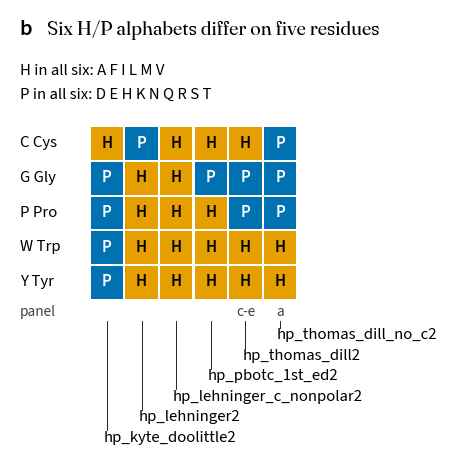

In [3]:
rust = git_show(KMERSEEK_REPO, KMERSEEK_COMMIT, "src/rust/alphabets.rs")
const_classes = {m[1]: (m[2], m[3]) for m in re.finditer(
    r"static (\w+): LazyLock<HashMap<u8, u8>> =\s*LazyLock::new\(\|\| build_hp\(b\"([A-Z]+)\", b\"([A-Z]+)\"\)\);", rust)}
variant_const = dict(re.findall(r"Self::(\w+) => &(\w+),", rust))
variant_name = dict(re.findall(r"Self::(\w+) => \"(hp_\w+)\",", rust))
hp_classes = {variant_name[v]: const_classes[c] for v, c in variant_const.items()
              if c in const_classes and v in variant_name}
check(set(HP_SIX) <= set(hp_classes), f"alphabets.rs at {KMERSEEK_COMMIT} lacks {set(HP_SIX) - set(hp_classes)}")
for a in HP_SIX:
    h, p = hp_classes[a]
    check(sorted(h + p) == sorted(STANDARD), f"{a} does not cover the 20 amino acids once")
    check([set(h), set(p)] == [set(x) for x in hc.ALPHABET_CLUSTERS[a]], f"{a} differs from hp_conservation_utils")
always_h = "".join(r for r in STANDARD if all(r in hp_classes[a][0] for a in HP_SIX))
always_p = "".join(r for r in STANDARD if all(r in hp_classes[a][1] for a in HP_SIX))
disputed = "".join(r for r in STANDARD if r not in always_h + always_p)
check(disputed == "CGPWY", f"residues the alphabets disagree on: {disputed}")
grid = pl.DataFrame([{"residue": r, **{a: ("H" if r in hp_classes[a][0] else "P") for a in HP_SIX}} for r in disputed])
print(f"kmerseek alphabets.rs at {KMERSEEK_COMMIT}. Same class in all six: H = {always_h}, P = {always_p}")
print(grid)
RESIDUE_NAME = {"C": "Cys", "G": "Gly", "P": "Pro", "W": "Trp", "Y": "Tyr"}
USED_IN = {HP_A: "a", HP: "c-e"}


def draw_panel_b(cv, ox, oy):
    """Grid of the disputed residues: one row per residue, one column per H/P alphabet."""
    cv.title(ox, oy + 52, "b", "Six H/P alphabets differ on five residues")
    cv.text(ox, oy + 47.5, f"H in all six: {' '.join(always_h)}", fontsize=6)
    cv.text(ox, oy + 44.5, f"P in all six: {' '.join(always_p)}", fontsize=6)
    sq, x0, y_top = 4.4, ox + 9, oy + 40.5
    for i, r in enumerate(disputed):
        y = y_top - (i + 0.5) * sq
        cv.text(ox, y, f"{r} {RESIDUE_NAME[r]}", fontsize=6)
        for j, a in enumerate(HP_SIX):
            c = "H" if r in hp_classes[a][0] else "P"
            cv.rect(x0 + j * sq, y - sq / 2, sq * 0.94, sq * 0.94, facecolor=C_H if c == "H" else C_P, edgecolor="none")
            cv.text(x0 + (j + 0.47) * sq, y + 0.1, c, fontsize=6, ha="center", fontweight="semibold",
                    color="black" if c == "H" else "white")
    y_used = y_top - len(disputed) * sq - 1.6
    cv.text(ox, y_used, "panel", fontsize=5.5, color="#444444")
    for j, a in enumerate(HP_SIX):
        if a in USED_IN:
            cv.text(x0 + (j + 0.47) * sq, y_used, USED_IN[a], fontsize=5.5, ha="center", color="#444444")
    # Column names, horizontal: the rightmost column's name on the top line, each with a line up to its column.
    y_lab = y_used - 3.0
    for n, j in enumerate(reversed(range(len(HP_SIX)))):
        xc = x0 + (j + 0.47) * sq
        y = y_lab - n * 2.6
        cv.line([xc, xc], [y_used - 1.2, y + 0.9], color="black", lw=0.3)
        cv.text(xc - 0.4, y, HP_SIX[j], fontsize=6, ha="left")


cv = Canvas(58, 58)
draw_panel_b(cv, 2, 2)
cv.fig.savefig(PANELS / "fig1b_hp_alphabets_disputed_residues_kmerseek_alphabets_rs.png", dpi=300)

## 3. How kmerseek finds the COL9A1 region (panel a)

Human COL9A1 (P20849) against chicken COL9A1 (P12106), alphabet `hp_thomas_dill_no_c2`, k = 19.
The four steps:

1. **Encode**: every residue becomes H or P.
2. **Seed**: every 19-letter H/P word shared by the two encoded proteins (a shared 19-mer). The
   shared 19-mers are recomputed here by encoding both full sequences, and checked against the 564
   in notebook 244's pair file.
3. **Region**: shared 19-mers that overlap on one diagonal (the same offset between human and chicken
   positions, no gap) are joined into one region.
4. **Label**: kmerseek's call, read from notebook 244's call table, is compared with the Swiss-Prot
   domain it falls in.

Coordinates are 1-based and inclusive, as in UniProt.

COL9A1, hp_thomas_dill_no_c2, k = 19: 564 shared 19-mers, 147 joined regions (both match notebook 244's pair file)
kmerseek call (kmerseek.hp_thomas_dill_no_c2_k19_lcTrue, notebook 244): human 669-700, chicken 667-698, 14 shared 19-mers joined; Swiss-Prot 'Collagen-like 7' 655-712

human    669 VGEPGPKGEQGASGEEGEAGERGELGDIGLPG 700
              ||||||||||| | || ||| | ||| |||| 25 of 32 identical
chicken  667 AGEPGPKGEQGAPGSEGDAGEKGDLGDMGLPG 698

human        HPPPPPPPPPPHPPPPPPHPPPPPHPPHPHPP
             |||||||||||||||||||||||||||||||| 32 of 32 same class
chicken      HPPPPPPPPPPHPPPPPPHPPPPPHPPHPHPP

H = AFILMVWY, P = CDEGHKNPQRST
shared 19-mers on the call's diagonal (human - chicken = 2): 84 of 564
shape: (14, 3)
┌─────────────┬───────────────┬─────────────────────┐
│ human_start ┆ chicken_start ┆ h_p_word            │
│ ---         ┆ ---           ┆ ---                 │
│ i64         ┆ i64           ┆ str                 │
╞═════════════╪═══════════════╪═════════════════════╡
│ 669

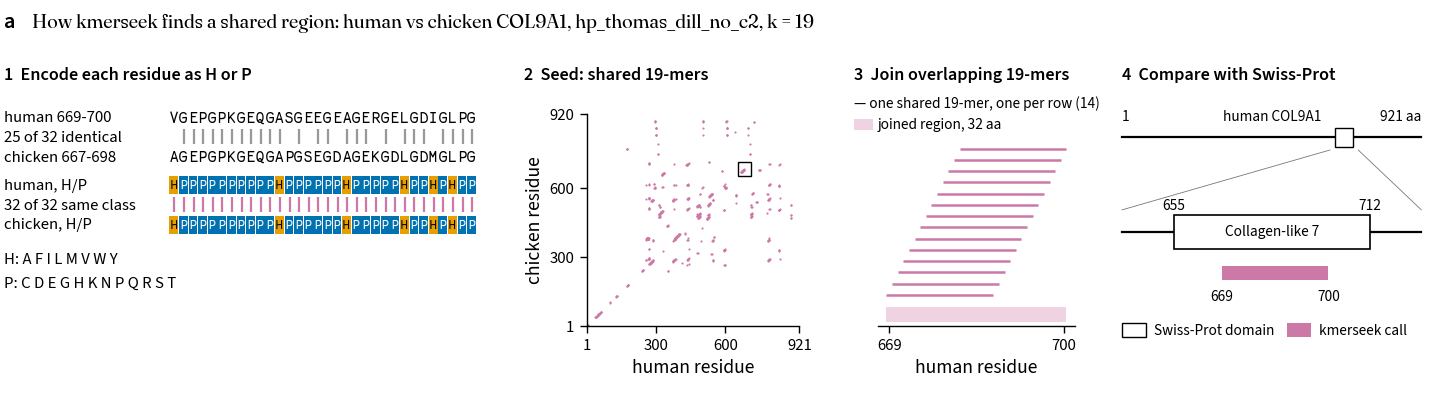

In [4]:
pair244 = json.loads(git_show(REPO, NB244_COMMIT, NB244_PAIR))
calls244 = pl.read_csv(git_show(REPO, NB244_COMMIT, NB244_CALLS).encode())
cand244 = pl.read_csv(git_show(REPO, NB244_COMMIT, NB244_CANDIDATES).encode(), infer_schema_length=0)
call = calls244.filter((pl.col("gene") == "COL9A1") & (pl.col("target") == CHICKEN)
                       & (pl.col("arm") == f"kmerseek.{HP_A}_k{K_A}_lcTrue")).row(0, named=True)
feature = cand244.filter((pl.col("query") == HUMAN) & (pl.col("target") == CHICKEN)).row(0, named=True)
q_full, t_full = pair244["query"]["sequence"], pair244["target"]["sequence"]
check(q_full == sprot_seqs[HUMAN] and t_full == sprot_seqs[CHICKEN], "244's sequences differ from Swiss-Prot 2026_03")
check(pair244["moltype"] == HP_A and pair244["ksize"] == K_A, "244 pair file is for another alphabet or k")
h_a, p_a = hp_classes[HP_A]
check(set(pair244["classes"]["h"]) == set(h_a), "244's H residues differ from alphabets.rs")
to_class_a = {r: ("H" if r in h_a else "P") for r in STANDARD}
q_cls = "".join(to_class_a[r] for r in q_full)
t_cls = "".join(to_class_a[r] for r in t_full)
check(q_cls == pair244["query"]["encoded"].upper() and t_cls == pair244["target"]["encoded"].upper(),
      "encoding differs from 244's")

# Seed: every shared 19-mer, as (human start, chicken start), 1-based.
target_words = {}
for j in range(len(t_cls) - K_A + 1):
    target_words.setdefault(t_cls[j:j + K_A], []).append(j)
shared = np.array([(i + 1, j + 1) for i in range(len(q_cls) - K_A + 1) for j in target_words.get(q_cls[i:i + K_A], [])])
check(len(shared) == len(pair244["shared_kmers"]), f"{len(shared)} shared 19-mers here, {len(pair244['shared_kmers'])} in 244")
check({tuple(x) for x in shared} == {(s["query_pos"] + 1, s["target_pos"] + 1) for s in pair244["shared_kmers"]},
      "shared 19-mer positions differ from 244's")

# Region: overlapping shared 19-mers on one diagonal, joined.
regions = []
for d in sorted(set(shared[:, 0] - shared[:, 1])):
    starts = np.sort(shared[shared[:, 0] - shared[:, 1] == d, 0])
    breaks = np.flatnonzero(np.diff(starts) > 1)
    for s, e in zip(np.r_[starts[0], starts[breaks + 1]], np.r_[starts[breaks], starts[-1]]):
        regions.append((int(s), int(e + K_A - 1), int(s - d), int(e + K_A - 1 - d)))
check(sorted(regions) == sorted((r["query_start"] + 1, r["query_end"], r["target_start"] + 1, r["target_end"])
                                for r in pair244["regions"]), "joined regions differ from 244's")
q0, q1, t0, t1 = call["query_start"], call["query_end"], call["target_start"], call["target_end"]
check((q0, q1, t0, t1) in regions, "kmerseek's call is not one of the joined regions")
call_kmers = shared[(shared[:, 0] - shared[:, 1] == q0 - t0) & (shared[:, 0] >= q0) & (shared[:, 0] + K_A - 1 <= q1)]
f0, f1 = int(feature["feature_start"]), int(feature["feature_end"])
q_reg, t_reg = q_full[q0 - 1:q1], t_full[t0 - 1:t1]
qc_reg, tc_reg = q_cls[q0 - 1:q1], t_cls[t0 - 1:t1]
n_ident_a = sum(a == b for a, b in zip(q_reg, t_reg))
n_same_a = sum(a == b for a, b in zip(qc_reg, tc_reg))
L_a = len(q_reg)

print(f"COL9A1, {HP_A}, k = {K_A}: {len(shared)} shared 19-mers, {len(regions)} joined regions "
      f"(both match notebook 244's pair file)")
print(f"kmerseek call ({call['arm']}, notebook 244): human {q0}-{q1}, chicken {t0}-{t1}, "
      f"{len(call_kmers)} shared 19-mers joined; Swiss-Prot '{feature['swissprot_description']}' {f0}-{f1}\n")
w = len("chicken")
print(f"{'human':<{w}} {q0:>4} {q_reg} {q1}")
print(f"{'':<{w}} {'':>4} {match_line(q_reg, t_reg)} {n_ident_a} of {L_a} identical")
print(f"{'chicken':<{w}} {t0:>4} {t_reg} {t1}\n")
print(f"{'human':<{w}} {'':>4} {qc_reg}")
print(f"{'':<{w}} {'':>4} {match_line(qc_reg, tc_reg)} {n_same_a} of {L_a} same class")
print(f"{'chicken':<{w}} {'':>4} {tc_reg}")
print(f"\nH = {h_a}, P = {p_a}")
n_on_call_diagonal = int((shared[:, 0] - shared[:, 1] == q0 - t0).sum())
print(f"shared 19-mers on the call's diagonal (human - chicken = {q0 - t0}): {n_on_call_diagonal} of {len(shared)}")
print(pl.DataFrame({"human_start": call_kmers[:, 0], "chicken_start": call_kmers[:, 1],
                    "h_p_word": [q_cls[i - 1:i - 1 + K_A] for i in call_kmers[:, 0]]}))


def draw_panel_a(cv, ox, oy):
    """Four steps, left to right: encode, seed, region, label."""
    cv.title(ox, oy + 47, "a", f"How kmerseek finds a shared region: human vs chicken COL9A1, "
             f"{HP_A}, k = {K_A}")
    # step 1, encode
    cv.text(ox, oy + 41, "1  Encode each residue as H or P", fontsize=6.5, fontweight="semibold")
    draw_pair_block(cv, ox, ox + 21, oy + 35.5, 1.22, ("human", "chicken"), (q0, t0), (q_reg, t_reg), (qc_reg, tc_reg))
    cv.text(ox, oy + 17.5, f"H: {' '.join(h_a)}", fontsize=6)
    cv.text(ox, oy + 14.5, f"P: {' '.join(p_a)}", fontsize=6)
    # step 2, seed
    x2 = ox + 74
    cv.text(x2 - 8, oy + 41, f"2  Seed: shared {K_A}-mers", fontsize=6.5, fontweight="semibold")
    ax2 = cv.axes(x2, oy + 9, 27, 27)
    ax2.scatter(shared[:, 0], shared[:, 1], s=0.6, color=C_HP, linewidths=0, rasterized=False)
    zoom = (q0 - 14, q1 + 14, t0 - 14, t1 + 14)
    ax2.add_patch(Rectangle((zoom[0], zoom[2]), zoom[1] - zoom[0], zoom[3] - zoom[2], fill=False, lw=0.5, ec="black"))
    ax2.set_xlim(0, len(q_full))
    ax2.set_ylim(0, len(t_full))
    ax2.set_xticks([1, 300, 600, 921][:-1] + [len(q_full)])
    ax2.set_yticks([1, 300, 600, len(t_full)])
    ax2.set_xlabel("human residue")
    ax2.set_ylabel("chicken residue")
    ax2.set_aspect("equal")
    # step 3, region
    x3 = ox + 111
    cv.text(x3 - 3, oy + 41, "3  Join overlapping 19-mers", fontsize=6.5, fontweight="semibold")
    ax3 = cv.axes(x3, oy + 9, 25, 24)
    for n, (i, j) in enumerate(call_kmers[np.argsort(call_kmers[:, 0])]):
        ax3.plot([i - 0.5, i + K_A - 0.5], [n + 2, n + 2], color=C_HP, lw=0.9, solid_capstyle="butt")
    ax3.add_patch(Rectangle((q0 - 0.5, -0.4), L_a, 1.3, facecolor=C_HP_PALE, edgecolor="none"))
    ax3.set_xlim(q0 - 2, q1 + 2)
    ax3.set_ylim(-0.8, len(call_kmers) + 2)
    ax3.set_xticks([q0, q1])
    ax3.set_yticks([])
    ax3.spines["left"].set_visible(False)
    ax3.set_xlabel("human residue")
    cv.text(x3 - 3, oy + 37.3, f"— one shared {K_A}-mer, one per row ({len(call_kmers)})", fontsize=5.5)
    cv.rect(x3 - 3, oy + 33.9, 2.4, 1.4, facecolor=C_HP_PALE, edgecolor="none")
    cv.text(x3, oy + 34.6, f"joined region, {L_a} aa", fontsize=5.5)
    # step 4, label
    x4 = ox + 142
    cv.text(x4, oy + 41, "4  Compare with Swiss-Prot", fontsize=6.5, fontweight="semibold")
    wd = 38.0
    sx = lambda r: x4 + (r - 1) / (len(q_full) - 1) * wd
    y_full = oy + 33
    cv.line([sx(1), sx(len(q_full))], [y_full, y_full], color="black", lw=0.8)
    cv.rect(sx(f0), y_full - 1.2, sx(f1) - sx(f0), 2.4, facecolor="white", edgecolor="black", lw=0.5, zorder=3)
    cv.text(sx(1), y_full + 2.6, "1", fontsize=5.5)
    cv.text((sx(1) + sx(len(q_full))) / 2, y_full + 2.6, "human COL9A1", fontsize=5.5, ha="center")
    cv.text(sx(len(q_full)), y_full + 2.6, f"{len(q_full)} aa", fontsize=5.5, ha="right")
    z0, z1 = f0 - 15, f1 + 15
    zx = lambda r: x4 + (r - z0) / (z1 - z0) * wd
    y_zoom = oy + 21
    cv.line([sx(z0), zx(z0)], [y_full - 1.6, y_zoom + 2.8], color="#777777", lw=0.3)
    cv.line([sx(z1), zx(z1)], [y_full - 1.6, y_zoom + 2.8], color="#777777", lw=0.3)
    cv.line([zx(z0), zx(z1)], [y_zoom, y_zoom], color="black", lw=0.8)
    cv.rect(zx(f0), y_zoom - 2.2, zx(f1) - zx(f0), 4.4, facecolor="white", edgecolor="black", lw=0.6, zorder=3)
    cv.text((zx(f0) + zx(f1)) / 2, y_zoom, feature["swissprot_description"], fontsize=5.5, ha="center", zorder=4)
    cv.text(zx(f0), y_zoom + 3.4, str(f0), fontsize=5.5, ha="center")
    cv.text(zx(f1), y_zoom + 3.4, str(f1), fontsize=5.5, ha="center")
    y_call = y_zoom - 5.2
    cv.rect(zx(q0), y_call - 0.9, zx(q1) - zx(q0), 1.8, facecolor=C_HP, edgecolor="none")
    cv.text(zx(q0), y_call - 3.0, str(q0), fontsize=5.5, ha="center")
    cv.text(zx(q1), y_call - 3.0, str(q1), fontsize=5.5, ha="center")
    cv.rect(x4, oy + 7.6, 3.0, 1.8, facecolor="white", edgecolor="black", lw=0.5)
    cv.text(x4 + 4, oy + 8.5, "Swiss-Prot domain", fontsize=5.5)
    cv.rect(x4 + 21, oy + 7.6, 3.0, 1.8, facecolor=C_HP, edgecolor="none")
    cv.text(x4 + 25, oy + 8.5, "kmerseek call", fontsize=5.5)
    return ax2, ax3


cv = Canvas(183, 52)
draw_panel_a(cv, 0, 2)
cv.fig.savefig(PANELS / "fig1a_col9a1_human_chicken_hp_thomas_dill_no_c2_k19.png", dpi=300)

## 4. Share of pairs whose longest same-class run reaches k (panel d)

Three curves for the 20-30% bin, `hp_thomas_dill2`:

1. **Real pairs**: notebook 230's longest same-class run per pair, recomputed from the alignments
   here and checked against the saved value.
2. **Predicted**: for each pair, `Pr(agree)` is its share of aligned positions in the same class
   (notebook 230's `agree`). If every aligned position agreed independently with that probability,
   the chance of a run of at least k is computed exactly by dynamic programming
   (`hc.pr_longest_run_at_least`), then averaged over pairs. A run stops at an alignment gap, as
   it does for the real pairs. A second version that joins each pair's aligned positions into one
   unbroken stretch is printed for comparison but not drawn.
3. **Shuffled**: the target's residues shuffled among its own residue positions (composition and
   gaps kept), 20 times per pair with a fixed seed, averaged over the shuffles.

The exact prediction is checked against simulation on five pairs.

shape: (15, 6)
┌───────┬───────────┬─────┬───────────┬────────┬───────────────┐
│ pair  ┆ Pr(agree) ┆ k   ┆ simulated ┆ exact  ┆ within 4 s.e. │
│ ---   ┆ ---       ┆ --- ┆ ---       ┆ ---    ┆ ---           │
│ i64   ┆ f64       ┆ i64 ┆ f64       ┆ f64    ┆ bool          │
╞═══════╪═══════════╪═════╪═══════════╪════════╪═══════════════╡
│ 0     ┆ 0.729     ┆ 8   ┆ 0.9964    ┆ 0.9961 ┆ true          │
│ 0     ┆ 0.729     ┆ 12  ┆ 0.6872    ┆ 0.6842 ┆ true          │
│ 0     ┆ 0.729     ┆ 16  ┆ 0.2218    ┆ 0.2284 ┆ true          │
│ 9271  ┆ 0.717     ┆ 8   ┆ 0.9918    ┆ 0.9919 ┆ true          │
│ 9271  ┆ 0.717     ┆ 12  ┆ 0.6356    ┆ 0.629  ┆ true          │
│ 9271  ┆ 0.717     ┆ 16  ┆ 0.2002    ┆ 0.1965 ┆ true          │
│ 18542 ┆ 0.783     ┆ 8   ┆ 0.9758    ┆ 0.9776 ┆ true          │
│ 18542 ┆ 0.783     ┆ 12  ┆ 0.5846    ┆ 0.5836 ┆ true          │
│ 18542 ┆ 0.783     ┆ 16  ┆ 0.1786    ┆ 0.1841 ┆ true          │
│ 27813 ┆ 0.846     ┆ 8   ┆ 0.9994    ┆ 0.9994 ┆ true          │
│ 27813 ┆ 

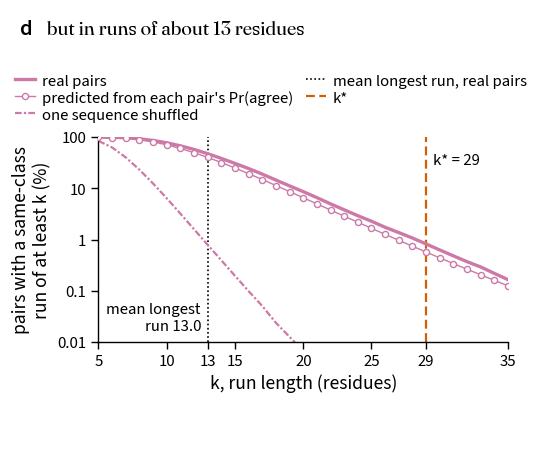

In [5]:
hp = pairs_all.filter((pl.col("alphabet") == HP) & (pl.col("identity_bin") == BIN))
aln = pl.read_parquet(ALIGNMENTS).select("family", "query", "target", "qaln", "taln")
hp_aln = hp.join(aln, on=["family", "query", "target"], how="inner").sort("family", "query", "target")
check(hp_aln.height == n_pairs == hp.height, "an alignment is missing for a pair in the bin")
tab = hc.TABLES[HP]
rng = np.random.default_rng(0)
real_runs = np.empty(n_pairs, dtype=np.int64)
null_runs = np.empty((N_SHUFFLE, n_pairs), dtype=np.int64)
stretches = []
for i, (qa_s, ta_s) in enumerate(hp_aln.select("qaln", "taln").iter_rows()):
    qcl = tab[np.frombuffer(qa_s.encode(), dtype=np.uint8)]
    tcl = tab[np.frombuffer(ta_s.encode(), dtype=np.uint8)]
    both = (qcl != hc.GAP) & (tcl != hc.GAP)
    real_runs[i] = hc.longest_true_run((qcl == tcl) & both)
    res_idx = np.flatnonzero(tcl != hc.GAP)
    for r in range(N_SHUFFLE):
        shuffled = tcl.copy()
        shuffled[res_idx] = tcl[rng.permutation(res_idx)]
        null_runs[r, i] = hc.longest_true_run((qcl == shuffled) & both)
    stretches.append(hc.aligned_stretches(qa_s, ta_s))
check(np.array_equal(real_runs, hp_aln["longest_run"].to_numpy()), "recomputed runs differ from 230's")
pr_agree = hp_aln["agree"].to_numpy()
n_aligned = hp_aln["n_cols"].to_numpy()
check(np.array_equal(np.array([s.sum() for s in stretches]), n_aligned), "stretch lengths do not add up to n_cols")

ks = np.array(KS)
pred_pair = hc.pr_longest_run_at_least(pr_agree, stretches, ks)
pred_one_pair = hc.pr_longest_run_at_least(pr_agree, [np.array([n]) for n in n_aligned], ks)
share_real = (real_runs[None, :] >= ks[:, None]).mean(axis=1)
share_pred = pred_pair.mean(axis=1)
share_pred_one = pred_one_pair.mean(axis=1)
share_null = (null_runs[:, None, :] >= ks[None, :, None]).mean(axis=2).mean(axis=0)
mean_run = float(real_runs.mean())
mean_run_null = float(null_runs.mean())
median_run = float(np.median(real_runs))

# Check the exact prediction against simulation on five pairs spread through the table.
sim_rng = np.random.default_rng(1)
sim_rows = []
for i in np.linspace(0, n_pairs - 1, 5).astype(int):
    best = np.zeros(N_SIM, dtype=np.int64)
    for L in stretches[i]:
        draws = sim_rng.random((N_SIM, L)) < pr_agree[i]
        padded = np.pad(draws, ((0, 0), (1, 1))).astype(np.int8)
        dd = np.diff(padded, axis=1)
        for s in range(N_SIM):
            st, en = np.flatnonzero(dd[s] == 1), np.flatnonzero(dd[s] == -1)
            if st.size:
                best[s] = max(best[s], (en - st).max())
    for k in (8, 12, 16):
        sim, exact = (best >= k).mean(), pred_pair[k - KS[0], i]
        sim_rows.append({"pair": i, "Pr(agree)": round(pr_agree[i], 3), "k": k, "simulated": sim, "exact": exact,
                         "within 4 s.e.": bool(abs(sim - exact) <= 4 * math.sqrt(max(exact * (1 - exact), 1e-12) / N_SIM))})
sim_check = pl.DataFrame(sim_rows)
print(sim_check.with_columns(pl.col("simulated", "exact").round(4)))
check(sim_check["within 4 s.e."].all(), "exact prediction disagrees with simulation")

# k*: hp_thomas_dill2 in Swiss-Prot 2026_03.
h_sp, p_sp = hp_classes[HP]
n_h = int(sum(sprot_counts[ord(r)] for r in h_sp))
n_p = int(sum(sprot_counts[ord(r)] for r in p_sp))
n_res = n_h + n_p
n_other = int(sprot_counts.sum()) - n_res
h_share, p_share = n_h / n_res, n_p / n_res
pr_same_chance = h_share * h_share + p_share * p_share  # h_query h_target + p_query p_target, both Swiss-Prot shares
b_alpha = -math.log2(pr_same_chance)
kstar_exact = math.log2(n_res) / b_alpha
kstar = math.ceil(kstar_exact)
print(f"\nSwiss-Prot 2026_03: {n_res:,} residues with an H/P class, {n_other:,} other letters; "
      f"h = {h_share:.4f}, p = {p_share:.4f}")
print(f"B_alpha = -log2({pr_same_chance:.4f}) = {b_alpha:.4f} bits; k* = ceil({math.log2(n_res):.3f} / {b_alpha:.4f}) "
      f"= ceil({kstar_exact:.2f}) = {kstar}")

at = lambda arr, k: float(arr[k - KS[0]])
tail = pl.DataFrame({
    "k": KS_TABLE,
    "real_pct": [100 * at(share_real, k) for k in KS_TABLE],
    "predicted_pct": [100 * at(share_pred, k) for k in KS_TABLE],
    "real_over_predicted": [at(share_real, k) / at(share_pred, k) for k in KS_TABLE],
    "predicted_one_stretch_pct": [100 * at(share_pred_one, k) for k in KS_TABLE],
    "real_over_one_stretch": [at(share_real, k) / at(share_pred_one, k) for k in KS_TABLE],
    "shuffled_pct": [100 * at(share_null, k) for k in KS_TABLE],
})
print(f"\nmean longest H/P run: real {mean_run:.2f} (median {median_run:.0f}), shuffled {mean_run_null:.2f}")
print(tail.with_columns(pl.exclude("k").round(3)))
ratio_lo = min(at(share_real, k) / at(share_pred, k) for k in range(19, KS[-1] + 1))
ratio_hi = max(at(share_real, k) / at(share_pred, k) for k in range(19, KS[-1] + 1))
first_above = min(k for k in KS if at(share_real, k) > at(share_pred, k))
print(f"real pairs above the prediction from k = {first_above}; at k = 19-{KS[-1]}, real / predicted = "
      f"{ratio_lo:.2f}-{ratio_hi:.2f}")
one_lo = min(at(share_real, k) / at(share_pred_one, k) for k in range(19, KS[-1] + 1))
one_hi = max(at(share_real, k) / at(share_pred_one, k) for k in range(19, KS[-1] + 1))
print(f"against the one-stretch version (runs allowed across gaps): real / predicted = {one_lo:.2f}-{one_hi:.2f}, "
      f"so real pairs sit below it at k >= 19")


def draw_panel_d(cv, ox, oy):
    """Share of pairs with a same-class run of at least k: real, predicted, shuffled; k* and the mean run."""
    cv.title(ox, oy + 52, "d", "but in runs of about 13 residues")
    ax = cv.axes(ox + 10, oy + 13, 52, 26)
    ax.plot(KS, 100 * share_pred, color=C_HP, lw=0.5, marker="o", ms=2.2, mfc="white", mew=0.5, zorder=4)
    ax.plot(KS, 100 * share_null, color=C_HP, lw=0.8, ls=(0, (3, 1, 1, 1)), zorder=2)
    ax.plot(KS, 100 * share_real, color=C_HP, lw=1.2, zorder=3)
    ax.axvline(kstar, color=C_KSTAR, lw=0.8, ls=(0, (4, 2)), zorder=0)
    ax.axvline(mean_run, color="black", lw=0.6, ls=(0, (1, 1.5)), zorder=0)
    ax.set_yscale("log")
    ax.set_ylim(0.01, 100)
    ax.set_yticks([0.01, 0.1, 1, 10, 100], ["0.01", "0.1", "1", "10", "100"])
    ax.minorticks_off()
    ax.set_xlim(KS[0], KS[-1])
    ax.set_xticks([5, 10, 13, 15, 20, 25, 29, 35] if kstar == 29 else [5, 10, 15, 20, 25, 30, 35])
    ax.set_xlabel("k, run length (residues)")
    ax.set_ylabel("pairs with a same-class\nrun of at least k (%)")
    ax.text(kstar + 0.5, 30, f"k* = {kstar}", fontsize=6, color="black")
    ax.text(mean_run - 0.5, 0.015, f"mean longest\nrun {mean_run:.1f}", fontsize=6, va="bottom", ha="right")
    handles = [Line2D([], [], color=C_HP, lw=1.2, label="real pairs"),
               Line2D([], [], color=C_HP, lw=0.5, marker="o", ms=2.2, mfc="white", mew=0.5,
                      label="predicted from each pair's Pr(agree)"),
               Line2D([], [], color=C_HP, lw=0.8, ls=(0, (3, 1, 1, 1)), label="one sequence shuffled"),
               Line2D([], [], color="black", lw=0.6, ls=(0, (1, 1.5)), label="mean longest run, real pairs"),
               Line2D([], [], color=C_KSTAR, lw=0.8, ls=(0, (4, 2)), label="k*")]
    ax.legend(handles=handles, loc="lower left", bbox_to_anchor=(-0.22, 1.04), ncol=2, borderaxespad=0,
              columnspacing=0.8, labelspacing=0.15)
    return ax


cv = Canvas(70, 58)
draw_panel_d(cv, 2, 2)
cv.fig.savefig(PANELS / "fig1d_hp_run_length_pfam_a_38.2_seed_20-30pct.png", dpi=300)

## 5. Helix, strand and coil: is secondary structure available for the seed pairs?

The brief asks to repeat the panel d comparison by DSSP helix, strand and coil if the seed
alignments carry secondary structure. Pfam stores it as `#=GR <sequence> SS` lines. The cell
counts every per-sequence (`#=GR`) and per-column (`#=GC`) annotation type in the Pfam-A 38.2 seed.

In [6]:
ann_counts = {}
with gzip.open(PFAM_SEED, "rb") as fh:
    for line in fh:
        if line.startswith(b"#=GR ") or line.startswith(b"#=GC "):
            parts = line.split()
            key = (parts[0].decode(), (parts[2] if parts[0] == b"#=GR" else parts[1]).decode())
            ann_counts[key] = ann_counts.get(key, 0) + 1
n_ss = sum(v for (kind, tag), v in ann_counts.items() if tag in ("SS", "SS_cons"))
print("annotation lines in Pfam-A 38.2 seed: " + "; ".join(f"{k} {t}: {v:,}" for (k, t), v in sorted(ann_counts.items())))
print(f"secondary-structure lines (SS or SS_cons): {n_ss}")

annotation lines in Pfam-A 38.2 seed: #=GC RF: 111; #=GC seq_cons: 30,134; #=GR AS: 658; #=GR pAS: 67,854; #=GR sAS: 13,398
secondary-structure lines (SS or SS_cons): 0


The seed file has no secondary-structure lines, so the helix, strand and coil split cannot be
made from the seed alignments. It would need structures mapped onto each seed sequence (PDB or
AlphaFold, then DSSP), which is a separate piece of work and is not in this figure.

## 6. One typical pair (panel e)

Rule, applied in code (the same as notebook 271's panel a): among the 20-30% pairs whose longest
H/P same-class run equals the bin's median, keep those with no gap, at most 80 aligned positions,
and both sequences reviewed Swiss-Prot entries (entry names that are not accessions); take the pair
whose own kappa is closest to the bin's mean kappa.

candidates after the rule: 3
shape: (3, 7)
┌─────────┬───────────┬──────────────────┬──────────────────┬────────┬───────────┬───────┐
│ family  ┆ family_id ┆ query            ┆ target           ┆ n_cols ┆ seqid_ali ┆ kappa │
│ ---     ┆ ---       ┆ ---              ┆ ---              ┆ ---    ┆ ---       ┆ ---   │
│ str     ┆ str       ┆ str              ┆ str              ┆ i64    ┆ f64       ┆ f64   │
╞═════════╪═══════════╪══════════════════╪══════════════════╪════════╪═══════════╪═══════╡
│ PF01418 ┆ HTH_6     ┆ RPIR_ECOLI/14-90 ┆ Y143_HAEIN/5-81  ┆ 77     ┆ 0.208     ┆ 0.451 │
│ PF01938 ┆ TRAM      ┆ YFJO_BACSU/11-68 ┆ RLMD_ECOLI/10-67 ┆ 58     ┆ 0.241     ┆ 0.488 │
│ PF08220 ┆ HTH_DeoR  ┆ ULAR_ECOLI/6-62  ┆ AGAR_ECOLI/18-74 ┆ 57     ┆ 0.263     ┆ 0.497 │
└─────────┴───────────┴──────────────────┴──────────────────┴────────┴───────────┴───────┘

Pfam PF01418 (HTH_6), 77 aligned positions, no gaps
RPIR_ECOLI   14 IGLAPYLRMKQEGMTENESRIVEWLLKPGNLSCAPAIKDVAEALAVSEAMIVKVSKLLGFSGFRNLRSA

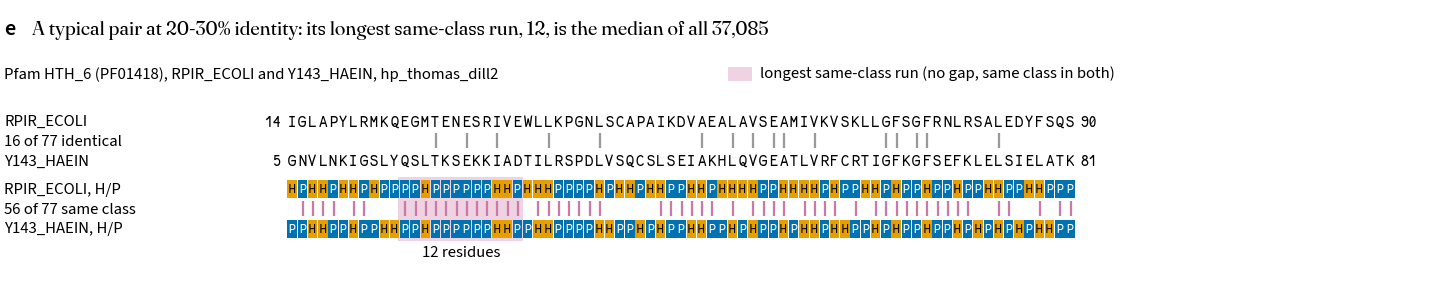

In [7]:
ACCESSION = re.compile(r"^([OPQ][0-9][A-Z0-9]{3}[0-9]|[A-NR-Z][0-9]([A-Z][A-Z0-9]{2}[0-9]){1,2})$")
reviewed = lambda seed_name: ACCESSION.match(seed_name.split("/")[0].split("_")[0]) is None
check(median_run == int(median_run), f"median run {median_run} is not a whole number")
cand = (
    hp_aln.filter(pl.col("longest_run") == int(median_run))
    .filter(pl.col("qaln").str.len_chars() == pl.col("n_cols"))
    .filter(pl.col("n_cols") <= PANEL_E_MAX_COLS)
    .filter(pl.col("query").map_elements(reviewed, return_dtype=pl.Boolean)
            & pl.col("target").map_elements(reviewed, return_dtype=pl.Boolean))
    .with_columns((pl.col("kappa") - hp["kappa"].mean()).abs().alias("kappa_distance"))
    .sort("kappa_distance", "family", "query")
)
print(f"candidates after the rule: {cand.height}")
print(cand.select("family", "family_id", "query", "target", "n_cols", pl.col("seqid_ali").round(3),
                  pl.col("kappa").round(3)).head(5))
pick = cand.row(0, named=True)
qe, te = pick["qaln"], pick["taln"]
L_e = len(qe)
to_class = {r: ("H" if r in h_sp else "P") for r in STANDARD}
qe_c = "".join(to_class[r] for r in qe)
te_c = "".join(to_class[r] for r in te)
cm_e = match_line(qe_c, te_c)
runs_e = [(m.start(), m.end()) for m in re.finditer(r"\|+", cm_e)]
longest_e = max(e - s for s, e in runs_e)
longest_runs_e = [(s, e) for s, e in runs_e if e - s == longest_e]
qname, qs_e, _ = seed_coords(pick["query"])
tname, ts_e, _ = seed_coords(pick["target"])
n_ident_e = match_line(qe, te).count("|")
n_same_e = cm_e.count("|")
check(longest_e == pick["longest_run"] == median_run, "longest run differs from 230's")
check(abs(n_same_e / L_e - pick["agree"]) < 1e-9, "class agreement differs from 230's")
w = max(len(qname), len(tname))
print(f"\nPfam {pick['family']} ({pick['family_id']}), {L_e} aligned positions, no gaps")
print(f"{qname:<{w}} {qs_e:>4} {qe} {qs_e + L_e - 1}")
print(f"{'':<{w}} {'':>4} {match_line(qe, te)} {n_ident_e} of {L_e} identical")
print(f"{tname:<{w}} {ts_e:>4} {te} {ts_e + L_e - 1}\n")
print(f"{qname:<{w}} {'':>4} {qe_c}")
print(f"{'':<{w}} {'':>4} {cm_e} {n_same_e} of {L_e} same class")
print(f"{tname:<{w}} {'':>4} {te_c}")
print(f"{'':<{w}} {'':>4} " + "".join("^" if any(s <= i < e for s, e in longest_runs_e) else " " for i in range(L_e))
      + f" longest same-class run: {longest_e}")


def draw_panel_e(cv, ox, oy):
    """The median pair, residues and H/P classes, longest same-class run shaded."""
    cv.title(ox, oy + 40, "e", f"A typical pair at {BIN} identity: its longest same-class run, {longest_e}, "
             f"is the median of all {n_pairs:,}")
    cv.text(ox, oy + 35, f"Pfam {pick['family_id']} ({pick['family']}), {qname} and {tname}, hp_thomas_dill2", fontsize=6)
    cv.rect(ox + 92, oy + 34.2, 3.0, 1.8, facecolor=C_HP_PALE, edgecolor="none")
    cv.text(ox + 96, oy + 35.1, "longest same-class run (no gap, same class in both)", fontsize=6)
    rows, _, _ = draw_pair_block(cv, ox, ox + 36, oy + 29, 1.3, (qname, tname), (qs_e, ts_e), (qe, te),
                                 (qe_c, te_c), shade=longest_runs_e, end_coords=True)
    for s, e in longest_runs_e:
        cv.text(ox + 36 + (s + e) / 2 * 1.3, rows["tc"] - 3.0, f"{e - s} residues", fontsize=6, ha="center")


cv = Canvas(183, 36)
draw_panel_e(cv, 0, -8)
cv.fig.savefig(PANELS / "fig1e_median_run_pair_pfam_a_38.2_seed_20-30pct.png", dpi=300)

## 7. Figure 1

183 mm wide (two Nature columns). Fonts: Fraunces for panel titles, Source Sans 3 for text,
Fantasque Sans Mono for sequences, embedded as TrueType so the text stays editable. One colour per
meaning in every panel: amber is H, blue is P, purple is the H/P alphabet, grey is the 20 amino
acids, the dashed coral line is k\*. The table compares every number in the brief with what was
computed; the notebook stops before drawing if any differs.

shape: (10, 5)
┌─────────────────────────────────┬─────────┬───────────┬──────────────────┬─────────┐
│ number                          ┆ brief   ┆ computed  ┆ computed_rounded ┆ matches │
│ ---                             ┆ ---     ┆ ---       ┆ ---              ┆ ---     │
│ str                             ┆ f64     ┆ f64       ┆ f64              ┆ bool    │
╞═════════════════════════════════╪═════════╪═══════════╪══════════════════╪═════════╡
│ pairs at 20-30% identity        ┆ 37085.0 ┆ 37085.0   ┆ 37085.0          ┆ true    │
│ kappa H/P (hp_thomas_dill2)     ┆ 0.46    ┆ 0.462555  ┆ 0.46             ┆ true    │
│ kappa 20 amino acids (protein2… ┆ 0.2     ┆ 0.198837  ┆ 0.2              ┆ true    │
│ mean longest H/P run, real      ┆ 13.0    ┆ 13.008251 ┆ 13.0             ┆ true    │
│ mean longest H/P run, shuffled  ┆ 6.3     ┆ 6.327875  ┆ 6.3              ┆ true    │
│ pairs with run >= 19 (%)        ┆ 11.0    ┆ 11.163543 ┆ 11.0             ┆ true    │
│ pairs with run >= 30 (%)  

fonts embedded in fig1.pdf: ['DHKLXC+SourceSans3-Regular', 'DHKLXC+SourceSans3-SemiBold', 'DKCQCQ+FantasqueSansMNFM-Regular', 'GQGMZL+Fraunces-72ptNonWonky', 'HDDGSM+FantasqueSansMNFM-Bold'] | TrueType: True


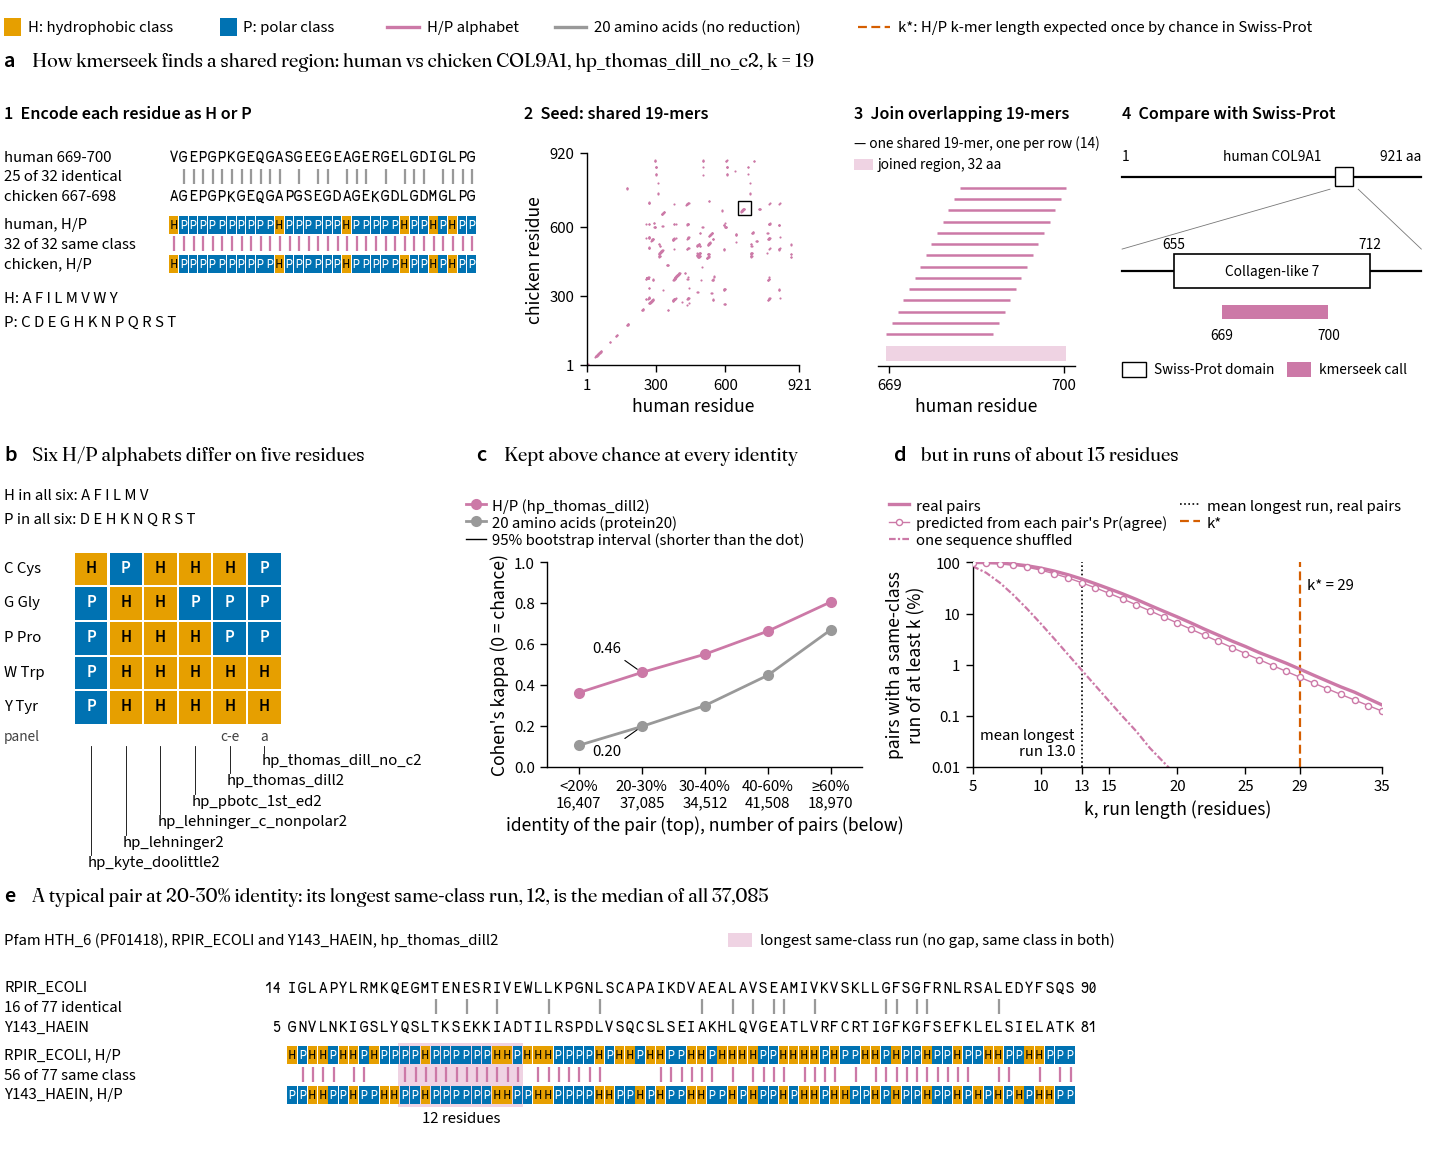

In [8]:
computed = {
    "pairs at 20-30% identity": n_pairs,
    "kappa H/P (hp_thomas_dill2)": kc[(HP, BIN)]["kappa"],
    "kappa 20 amino acids (protein20)": kc[(AA, BIN)]["kappa"],
    "mean longest H/P run, real": mean_run,
    "mean longest H/P run, shuffled": mean_run_null,
    "pairs with run >= 19 (%)": 100 * at(share_real, 19),
    "pairs with run >= 30 (%)": 100 * at(share_real, 30),
    "COL9A1 identical (of 32)": n_ident_a,
    "COL9A1 same class (of 32)": n_same_a,
}
brief = pl.DataFrame([{"number": k, "brief": v, "computed": computed[k], "computed_rounded": round(computed[k], d),
                       "matches": round(computed[k], d) == v} for k, (v, d) in EXPECTED.items()]
                     + [{"number": "k*", "brief": 29.0, "computed": float(kstar), "computed_rounded": float(kstar),
                         "matches": 28 <= kstar <= 30}])
print(brief)
check(brief["matches"].all() and L_a == 32, "a number differs from the brief:\n" + str(brief.filter(~pl.col("matches"))))

W, H = pf.TWO_COLUMN_MM, 146
cv = Canvas(W, H)
# Legend for the colours every panel shares, above all panels.
lx, ly = 0, H - 3
items = [("sq", C_H, "H: hydrophobic class"), ("sq", C_P, "P: polar class"), ("ln", C_HP, "H/P alphabet"),
         ("ln", C_AA, "20 amino acids (no reduction)"), ("ks", C_KSTAR, f"k*: H/P k-mer length expected once by chance in Swiss-Prot")]
for kind, color, label in items:
    if kind == "sq":
        cv.rect(lx, ly - 1.1, 2.2, 2.2, facecolor=color, edgecolor="none")
    else:
        cv.line([lx, lx + 4], [ly, ly], color=color, lw=1.2 if kind == "ln" else 0.8,
                ls="-" if kind == "ln" else (0, (4, 2)))
    cv.text(lx + (3 if kind == "sq" else 5), ly, label, fontsize=6)
    lx += (3 if kind == "sq" else 5) + 1.02 * len(label) + 4
draw_panel_a(cv, 0, 91)
draw_panel_b(cv, 0, 36)
draw_panel_c(cv, 60, 36)
draw_panel_d(cv, 113, 36)
draw_panel_e(cv, 0, -8)
cv.fig.savefig(FIG / "fig1.pdf")
cv.fig.savefig(FIG / "fig1.png", dpi=450)
pdf = (FIG / "fig1.pdf").read_bytes()
fonts = sorted(set(re.findall(rb"/BaseFont /([A-Za-z0-9+_-]+)", pdf)))
print("fonts embedded in fig1.pdf:", [f.decode() for f in fonts], "| TrueType:", b"/FontFile2" in pdf)
check(not any(b"DejaVu" in f for f in fonts), "a DejaVu fallback font is in the PDF")

## 8. Caption and the values behind it

Every number in the caption is formatted from a variable computed above, and the same values are
written to `figures/fig1_values.json`.

In [9]:
values = {
    "pfam_release": "Pfam-A 38.2 seed", "identity_bin": BIN, "min_aligned_positions": MIN_COLS,
    "n_pairs": n_pairs, "n_families": hp["family"].n_unique(),
    "panel_a": {"human": HUMAN, "chicken": CHICKEN, "alphabet": HP_A, "k": K_A, "kmerseek_call_arm": call["arm"],
                "human_region": [q0, q1], "chicken_region": [t0, t1], "positions": L_a, "identical": n_ident_a,
                "same_class": n_same_a, "n_shared_19mers": int(len(shared)), "n_joined_regions": len(regions),
                "n_19mers_in_call": int(len(call_kmers)), "swissprot_feature": feature["swissprot_description"],
                "swissprot_feature_range": [f0, f1], "human_length": len(q_full), "chicken_length": len(t_full),
                "nb244_commit": NB244_COMMIT},
    "panel_b": {"kmerseek_commit": KMERSEEK_COMMIT, "always_h": always_h, "always_p": always_p,
                "classes": {a: {"H": hp_classes[a][0], "P": hp_classes[a][1]} for a in HP_SIX}},
    "panel_c": [{k: r[k] for k in ("alphabet", "identity_bin", "n_pairs", "kappa", "kappa_lo", "kappa_hi")}
                for r in kappa_bins.iter_rows(named=True)],
    "panel_d": {"n_shuffles": N_SHUFFLE, "mean_longest_run_real": mean_run, "median_longest_run_real": median_run,
                "mean_longest_run_shuffled": mean_run_null, "first_k_real_above_predicted": first_above,
                "real_over_predicted_k19_to_35": [ratio_lo, ratio_hi],
                "real_over_one_stretch_k19_to_35": [one_lo, one_hi],
                "share_at_k": {int(k): {"real": at(share_real, k), "predicted": at(share_pred, k),
                                        "predicted_one_stretch": at(share_pred_one, k), "shuffled": at(share_null, k)}
                               for k in KS}},
    "kstar": {"swissprot": "2026_03", "n_residues_with_class": n_res, "n_other_letters": n_other,
              "h": h_share, "p": p_share, "pr_same_by_chance": pr_same_chance, "b_alpha": b_alpha,
              "kstar_exact": kstar_exact, "kstar": kstar},
    "secondary_structure_lines_in_seed": n_ss,
    "panel_e": {"family": pick["family"], "family_id": pick["family_id"], "query": pick["query"], "target": pick["target"],
                "positions": L_e, "identical": n_ident_e, "same_class": n_same_e, "longest_run": longest_e,
                "bin_median_longest_run": median_run, "n_candidates": cand.height},
}
(FIG / "fig1_values.json").write_text(json.dumps(values, indent=1, default=float))

hpk, aak = kc[(HP, BIN)], kc[(AA, BIN)]
lo_bin, hi_bin = hc.IDENTITY_LABELS[0], hc.IDENTITY_LABELS[-1]
caption = f"""**Figure 1 | Between related proteins, the hydrophobic/polar (H/P) class of each residue is kept well above chance, but in runs of about {mean_run:.0f} residues.**
Amber marks the hydrophobic class (H), blue the polar class (P), purple an H/P alphabet and grey the 20 amino acids in every panel.
**a**, How kmerseek finds a shared region, on human COL9A1 (P20849, {len(q_full)} aa) and chicken COL9A1 (P12106, {len(t_full)} aa) with the {HP_A} alphabet and k = {K_A}. (1) Each residue is encoded as H or P; in human {q0}–{q1} and chicken {t0}–{t1}, {n_ident_a} of {L_a} residues are identical and {n_same_a} of {L_a} have the same class. (2) Every 19-letter H/P word the two encoded proteins share is a seed: {len(shared)} shared 19-mers, each dot at its human and chicken start position. The box marks the area shown in step 3. (3) Shared 19-mers that overlap on one diagonal, with no gap, are joined into a region; the {len(call_kmers)} 19-mers here make one {L_a}-residue region. Each row is one shared 19-mer; the pale bar under them is the joined region. (4) kmerseek's call (purple bar; kmerseek 0.3.1, from notebook 244) lies inside Swiss-Prot's {feature['swissprot_description']} domain, residues {f0}–{f1}.
**b**, The six H/P alphabets in kmerseek put {' '.join(always_h)} in H and {' '.join(always_p)} in P, and differ on {', '.join(disputed[:-1])} and {disputed[-1]}. Panel a uses {HP_A}; panels c–e use {HP}.
**c**, Cohen's kappa, the agreement of the classes of aligned residues corrected for chance (0 is chance, 1 is every aligned residue in the same class), for pairs of sequences from the same Pfam-A 38.2 seed alignment with at least {MIN_COLS} aligned positions, by percent identity. Mean over pairs, with 95% bootstrap intervals over pairs (shorter than the dots). At {BIN.replace('-', '–')} identity ({n_pairs:,} pairs from {hp['family'].n_unique():,} families), kappa is {hpk['kappa']:.2f} for H/P ({hpk['kappa_lo']:.4f}–{hpk['kappa_hi']:.4f}) and {aak['kappa']:.2f} for the 20 amino acids ({aak['kappa_lo']:.4f}–{aak['kappa_hi']:.4f}); from {BIN_SHOWN[lo_bin]} to {BIN_SHOWN[hi_bin]} identity, H/P kappa rises from {kc[(HP, lo_bin)]['kappa']:.2f} to {kc[(HP, hi_bin)]['kappa']:.2f}.
**d**, Share of the {n_pairs:,} pairs at {BIN.replace('-', '–')} identity whose longest same-class run (aligned positions in a row, no gap, same class in both) is at least k. The vertical axis is spaced by ratio: the step from 0.1% to 1% takes as much room as the step from 1% to 10%. Real pairs: mean longest run {mean_run:.1f} residues (median {median_run:.0f}); {pct(at(share_real, 19))} of pairs reach k = 19 and {pct(at(share_real, 30))} reach k = 30. Predicted (open circles): for each pair, Pr(agree) is its share of aligned positions in the same class; the curve is the mean over pairs of the exact chance of a run of at least k if every aligned position agreed independently with that pair's Pr(agree), with runs stopped at alignment gaps. Real pairs sit above the prediction from k = {first_above} on, by a factor of {ratio_lo:.1f}–{ratio_hi:.1f} at k = 19–{KS[-1]} ({pct(at(share_real, 30))} against {pct(at(share_pred, 30))} at k = 30). One sequence shuffled ({N_SHUFFLE} shuffles per pair, composition and gaps kept): mean longest run {mean_run_null:.1f}, {pct(at(share_null, 19))} of pairs reach k = 19. Dashed coral line: k* = {kstar}, the H/P k-mer length at which one chance match is expected across Swiss-Prot 2026_03; k* = ⌈log2 N / B_α⌉, with N = {n_res:,} residues and B_α = −log2(h_query·h_target + p_query·p_target) = {b_alpha:.3f} bits per letter, where h_query = h_target = {h_share:.3f} and p_query = p_target = {p_share:.3f} are the Swiss-Prot hydrophobic and polar shares. {pct(at(share_real, kstar))} of real pairs reach k*.
**e**, One of these pairs, {qname} residues {qs_e}–{qs_e + L_e - 1} and {tname} residues {ts_e}–{ts_e + L_e - 1} (Pfam {pick['family_id']}, {pick['family']}), chosen because its longest same-class run ({longest_e} residues, shaded) equals the median of all {n_pairs:,} pairs. {n_ident_e} of {L_e} residues are identical and {n_same_e} of {L_e} have the same H/P class.
"""
(FIG / "fig1_caption.md").write_text(caption)
print(caption)
print(f"caption words: {len(re.sub(r'[*]', '', caption).split())}")

**Figure 1 | Between related proteins, the hydrophobic/polar (H/P) class of each residue is kept well above chance, but in runs of about 13 residues.**
Amber marks the hydrophobic class (H), blue the polar class (P), purple an H/P alphabet and grey the 20 amino acids in every panel.
**a**, How kmerseek finds a shared region, on human COL9A1 (P20849, 921 aa) and chicken COL9A1 (P12106, 920 aa) with the hp_thomas_dill_no_c2 alphabet and k = 19. (1) Each residue is encoded as H or P; in human 669–700 and chicken 667–698, 25 of 32 residues are identical and 32 of 32 have the same class. (2) Every 19-letter H/P word the two encoded proteins share is a seed: 564 shared 19-mers, each dot at its human and chicken start position. The box marks the area shown in step 3. (3) Shared 19-mers that overlap on one diagonal, with no gap, are joined into a region; the 14 19-mers here make one 32-residue region. Each row is one shared 19-mer; the pale bar under them is the joined region. (4) kmerseek's c

## Summary and conclusions

The numbers below are printed by the cells above and saved in `figures/fig1_values.json`; the
caption in `figures/fig1_caption.md` is formatted from the same variables.

1. Every number in the brief matched what was computed (section 7): 37,085 pairs, kappa 0.46 for
   H/P and 0.20 for the 20 amino acids at 20-30% identity, mean longest H/P run 13.0 (6.3 with one
   sequence shuffled), 11.2% of pairs reaching k = 19 and 0.63% reaching k = 30, k\* = 29, and 25 of
   32 identical and 32 of 32 same class in the COL9A1 region.
2. H/P kappa is above the 20-amino-acid kappa in every identity bin (panel c). Higher kappa means
   more of the class pattern is kept between the two sequences; 0 would be chance.
3. Long same-class runs are a little more common than independent positions would give. Real pairs
   sit 1.29-1.44 times above the exact prediction at k = 19-35 when runs stop at gaps, as real runs
   do (0.63% against 0.44% at k = 30). If each pair's aligned positions are instead joined into one
   unbroken stretch, the prediction rises above the real pairs (real / predicted 0.50-0.78 at
   k = 19-35), so the direction of this comparison depends on how gaps are treated. Both
   predictions sit far above the shuffled pairs, which almost never reach k = 19 (0.013%).
4. Panel a's COL9A1 call joins 14 overlapping shared 19-mers into a 32-residue region at human
   669-700, inside Swiss-Prot's Collagen-like 7 domain (655-712). The two proteins share 564 H/P
   19-mers in all; 84 lie on the diagonal of the call (the same human-chicken offset), 480 off it.
5. The helix, strand and coil split was not made: the Pfam-A 38.2 seed has no secondary-structure
   lines (section 5).